<a href="https://colab.research.google.com/github/erickgnfi-dotcom/Analisis-Exploratorio-de-Datos-con-Pandas/blob/main/ETL_restcountries_API.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
"""
ETL Pipeline - CoinGecko
Arquitectura Medallion: Bronze → Silver → Gold
"""

import requests
import pandas as pd
import json
from datetime import datetime
from typing import Dict, List
import time

In [ ]:
"""
Extrae datos crudos de la API y los almacena sin transofmar
"""
response = requests.get(f'https://restcountries.com/v3.1/all?fields=name,currencies,region,area,continents,languages,population')
response.json()[1]

{'name': {'common': 'Chile',
  'official': 'Republic of Chile',
  'nativeName': {'spa': {'official': 'República de Chile',
    'common': 'Chile'}}},
 'currencies': {'CLP': {'name': 'Chilean peso', 'symbol': '$'}},
 'region': 'Americas',
 'languages': {'spa': 'Spanish'},
 'area': 756102.0,
 'population': 19116209,
 'continents': ['South America']}

In [ ]:
list(response.json()[1]['languages'].values())[0]

'Spanish'

In [240]:
"""Transforma y limpia los datos del bronze layer"""
df = []
for country in response.json():
    country_data = {'Pais': country['name']['common']}
    try:
        # Attempt to access the currency name
        country_data['Moneda'] = list(country['currencies'].values())[0]['name']
    except (KeyError, IndexError):
        # Handle cases where 'currencies' key is missing, dictionary is empty,
        # or index is out of range
        country_data['Moneda'] = None # Or some other placeholder like 'N/A'
    country_data['Region'] = country['region']
    country_data['Area'] = country['area']
    country_data['Continente'] = country['continents'][0]
    try:
      country_data['Idiomas'] = list(country['languages'].values())[0]
    except (KeyError, IndexError):
        country_data['Idiomas'] = None
    country_data['Poblacion'] = country['population']
    df.append(country_data)

# Convert the list of dictionaries to a pandas DataFrame
df = pd.DataFrame(df)
df['Densidad_Poblacional'] = df['Poblacion'] / df['Area']
df.head()

,Pais,Moneda,Region,Area,Continente,Idiomas,Poblacion,Densidad_Poblacional
0,Lithuania,Euro,Europe,65300.0,Europe,Lithuanian,2794700,42.797856
1,Chile,Chilean peso,Americas,756102.0,South America,Spanish,19116209,25.282580
2,Benin,West African CFA franc,Africa,112622.0,Africa,French,12123198,107.645025
3,Falkland Islands,Falkland Islands pound,Americas,12173.0,South America,English,2563,0.210548
4,Georgia,lari,Asia,69700.0,Asia,Georgian,3714000,53.285509


In [313]:
#Crear resumen por continente

df_densidad = pd.DataFrame(df.groupby('Continente')['Densidad_Poblacional'].mean())
df_cuenta_paises = pd.DataFrame(df.groupby('Continente')['Pais'].count())
df_cuenta_idiomas = df.groupby('Continente')['Idiomas'].nunique()
df_complemento = df.groupby('Continente')[['Area', 'Poblacion']].sum()

df_continente = df_densidad.merge(df_cuenta_paises, on='Continente', how='left')
df_continente = df_continente.merge(df_cuenta_idiomas, on='Continente', how='left')
df_continente = df_continente.merge(df_complemento, on='Continente', how='left')

df_continente.reset_index(inplace=True)
df_continente

,Continente,Densidad_Poblacional,Pais,Idiomas,Area,Poblacion
0,Africa,114.8148,58,9,30318357.0000,1362092235
1,Antarctica,0.0119,5,3,14012111.0000,1430
2,Asia,987.4451,50,26,31253314.0000,4508832965
3,Europe,641.2750,55,36,23954459.4600,841383255
4,North America,258.1455,41,6,24244506.0000,590080423
5,Oceania,119.7767,27,6,8530072.2000,44435558
6,South America,20.6707,14,7,17833382.0000,430895697


In [295]:
pd.set_option('display.float_format', '{:.4f}'.format)
df['Area'].describe()

,Area
count,250.0000
mean,600584.8066
std,1909804.9110
min,0.4400
25%,1194.2500
50%,64929.5000
75%,372726.0000
max,17098242.0000


In [289]:
pd.cut(df['Area'], bins=[30, 84, 225, float('inf')], labels=['Bajo', 'Medio', 'Alto'])

,Densidad_Poblacional
0,Low
1,NaN
2,Medium
3,NaN
4,Low
...,...
245,Low
246,Medium
247,Medium
248,Low


In [300]:
df_pais=df[['Pais','Idiomas','Continente','Densidad_Poblacional','Area']]

df_categoria_densidad = pd.cut(df['Densidad_Poblacional'], bins=[0, 30, 84, 225, float('inf')], labels=['Nulo', 'Bajo', 'Medio', 'Alto'])
df_pais['Categoria_Densidad'] = df_categoria_densidad

df_categoria_area = pd.cut(df['Area'], bins=[1195, 64929, 372726, float('inf')], labels=['Pequeño', 'Mediano', 'Grande'])
df_pais['Categoria_Area'] = df_categoria_area

df_pais

/tmp/ipython-input-2850069634.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_pais['Categoria_Densidad'] = df_categoria_densidad
/tmp/ipython-input-2850069634.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_pais['Categoria_Area'] = df_categoria_area


,Pais,Idiomas,Continente,Densidad_Poblacional,Area,Categoria_Densidad,Categoria_Area
0,Lithuania,Lithuanian,Europe,42.7979,65300.0000,Bajo,Mediano
1,Chile,Spanish,South America,25.2826,756102.0000,Nulo,Grande
2,Benin,French,Africa,107.6450,112622.0000,Medio,Mediano
3,Falkland Islands,English,South America,0.2105,12173.0000,Nulo,Pequeño
4,Georgia,Georgian,Asia,53.2855,69700.0000,Bajo,Mediano
...,...,...,...,...,...,...,...
245,Colombia,Spanish,South America,44.5658,1141748.0000,Bajo,Grande
246,Poland,Polish,Europe,121.3730,312679.0000,Medio,Mediano
247,Turkey,Turkish,Europe,107.6355,783562.0000,Medio,Grande
248,Brunei,Malay,Asia,75.8860,5765.0000,Bajo,Pequeño


In [301]:
df_pais.pivot_table(index='Continente', columns='Categoria_Densidad', values='Pais', aggfunc='count')

/tmp/ipython-input-310982457.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df_pais.pivot_table(index='Continente', columns='Categoria_Densidad', values='Pais', aggfunc='count')


Categoria_Densidad,Nulo,Bajo,Medio,Alto
Continente,,,,
Africa,17,19,14,8
Antarctica,3,0,0,0
Asia,7,12,12,19
Europe,9,14,19,13
North America,5,7,11,18
Oceania,9,7,6,5
South America,11,3,0,0


In [305]:
import matplotlib.pyplot as plt

(array([2., 2., 1., 0., 0., 0., 1., 0., 0., 1.]),
 array([1.18781428e-02, 9.87552050e+01, 1.97498532e+02, 2.96241859e+02,
        3.94985186e+02, 4.93728513e+02, 5.92471839e+02, 6.91215166e+02,
        7.89958493e+02, 8.88701820e+02, 9.87445147e+02]),
 <BarContainer object of 10 artists>)

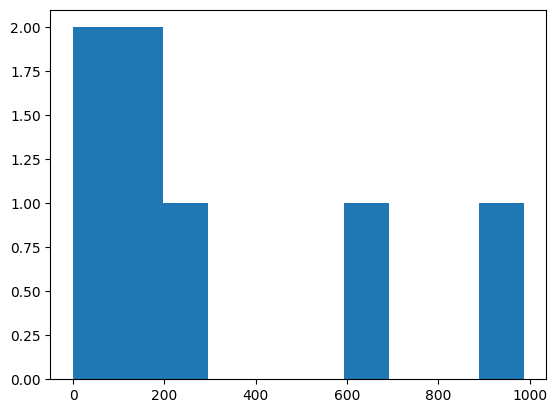

In [311]:
plt.hist(df_continente['Densidad_Poblacional'])

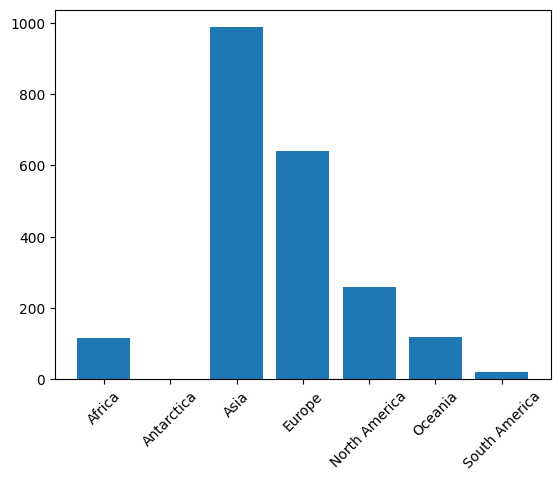

In [318]:
plt.bar(df_continente['Continente'], df_continente['Densidad_Poblacional'])
plt.xticks(rotation=45)

plt.show()